In [ ]:
#Nguyễn Anh Vũ

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
import time

#  Khai báo các tham số
DATASET_PATH = "/content/drive/MyDrive/datadoan/plant-health"
IMG_SIZE = (224, 224)  # thống nhất với generator
BATCH_SIZE = 32
EPOCHS = 20

#  ImageDataGenerator
datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)

#  Train generator
train_generator = datagen.flow_from_directory(
    directory=DATASET_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    subset="training",
    shuffle=True
)

#  Validation generator
val_generator = datagen.flow_from_directory(
    directory=DATASET_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    subset="validation",
    shuffle=False
)



Found 566 images belonging to 2 classes.
Found 141 images belonging to 2 classes.


In [ ]:
#  MobileNetV2
base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(*IMG_SIZE, 3)  # (224,224,3)
)

base_model.trainable = False  # đóng băng backbone

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation="relu")(x)
x = Dropout(0.5)(x)
output = Dense(1, activation="sigmoid")(x)

model = Model(inputs=base_model.input, outputs=output)

# Compile model
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)



In [ ]:
# Train model
start_time = time.time()

history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator
)

train_time = time.time() - start_time
print(f" Thời gian huấn luyện: {train_time:.2f} giây")


Epoch 1/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 64s 3s/step - accuracy: 0.5640 - loss: 0.7873 - val_accuracy: 0.5461 - val_loss: 0.6821
Epoch 2/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 57s 3s/step - accuracy: 0.6612 - loss: 0.5965 - val_accuracy: 0.5816 - val_loss: 0.6946
Epoch 3/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 66s 4s/step - accuracy: 0.7555 - loss: 0.4533 - val_accuracy: 0.5177 - val_loss: 0.7014
Epoch 4/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 54s 3s/step - accuracy: 0.7621 - loss: 0.4763 - val_accuracy: 0.4610 - val_loss: 0.7749
Epoch 5/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 55s 3s/step - accuracy: 0.8320 - loss: 0.4171 - val_accuracy: 0.5035 - val_loss: 0.7791
Epoch 6/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 53s 3s/step - accuracy: 0.8316 - loss: 0.3931 - val_accuracy: 0.4752 - val_loss: 0.7886
Epoch 7/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 54s 3s/step - accuracy: 0.8763 - loss: 0.3379 - val_accuracy: 0.4681 - val_loss: 0.8652
Epoch 8/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 52s 3s/step - accuracy: 0.8282 - loss: 0.3765 - val_accuracy: 0.5106 - val_loss:

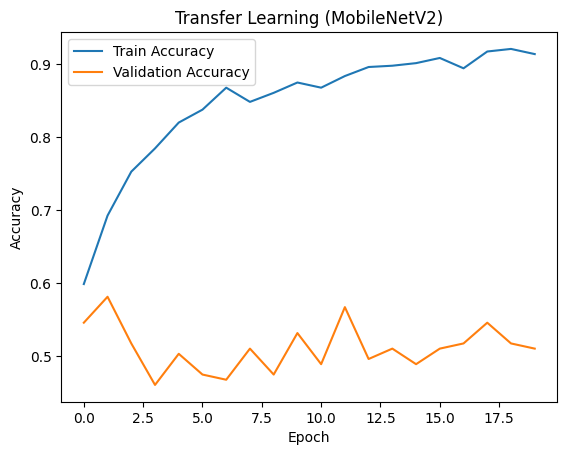

In [ ]:
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Transfer Learning (MobileNetV2)")
plt.legend()
plt.show()


5/5 ━━━━━━━━━━━━━━━━━━━━ 12s 2s/step
Accuracy trên tập validation: 0.5177

Classification Report:
              precision    recall  f1-score   support

     healthy       0.49      0.97      0.65        65
   unhealthy       0.83      0.13      0.23        76

    accuracy                           0.52       141
   macro avg       0.66      0.55      0.44       141
weighted avg       0.67      0.52      0.42       141



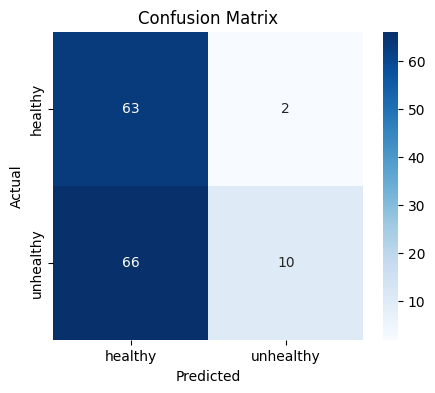

In [ ]:
# Import các hàm cần thiết
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Lấy nhãn thật
y_true = val_generator.classes

# Dự đoán
y_pred_prob = model.predict(val_generator)           # ra xác suất
y_pred = (y_pred_prob > 0.5).astype(int).ravel()    # chuyển sang nhãn 0 hoặc 1

# Accuracy
acc = accuracy_score(y_true, y_pred)
print(f"Accuracy trên tập validation: {acc:.4f}\n")

# Classification Report
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=val_generator.class_indices.keys()))

# Confusion Matrix trực quan
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=val_generator.class_indices.keys(),
            yticklabels=val_generator.class_indices.keys())
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


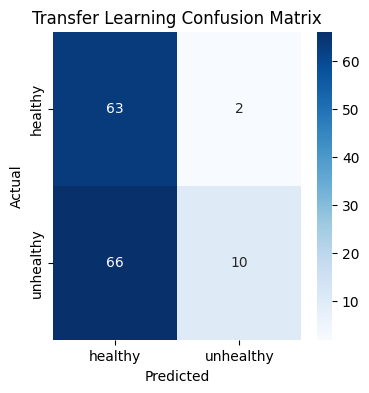

In [ ]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(4,4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["healthy", "unhealthy"],
    yticklabels=["healthy", "unhealthy"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Transfer Learning Confusion Matrix")
plt.show()


In [ ]:
print(f"Thời gian huấn luyện: {train_time:.2f} giây")


Thời gian huấn luyện: 1121.60 giây
